In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/GiveMeSomeCredit/Data Dictionary.xls
/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv
/kaggle/input/competitions/GiveMeSomeCredit/sampleEntry.csv
/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✓ Libraries imported!")

✓ Libraries imported!


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/GiveMeSomeCredit/Data Dictionary.xls
/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv
/kaggle/input/competitions/GiveMeSomeCredit/sampleEntry.csv
/kaggle/input/competitions/GiveMeSomeCredit/cs-test.csv


In [4]:
import pandas as pd

print("=" * 70)
print("LOADING DATA")
print("=" * 70)

data = pd.read_csv('/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv')

print("\n✓ Data loaded!")
print(f"Shape: {data.shape}")

print("\nFirst 3 rows:")
print(data.head(3))

LOADING DATA

✓ Data loaded!
Shape: (150000, 12)

First 3 rows:
   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                        0   
1                                4                        0   
2                                2                        1   

   NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  \
0                   

In [5]:
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nTarget distribution:")
print(data['SeriousDlqin2yrs'].value_counts())
print(f"\nDefault Rate: {data['SeriousDlqin2yrs'].mean():.2%}")

print("\nMissing Values:")
missing = data.isnull().sum()
print(missing[missing > 0])

print("\nBasic Statistics:")
print(data.describe())


EXPLORATORY DATA ANALYSIS

Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Default Rate: 6.68%

Missing Values:
MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64

Basic Statistics:
          Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
count  150000.000000     150000.000000                         150000.000000   
mean    75000.500000          0.066840                              6.048438   
std     43301.414527          0.249746                            249.755371   
min         1.000000          0.000000                              0.000000   
25%     37500.750000          0.000000                              0.029867   
50%     75000.500000          0.000000                              0.154181   
75%    112500.250000          0.000000                              0.559046   
max    150000.000000          1.000000                          50708.000000   

                 age  NumberOfTime30-

In [6]:
print("\n" + "=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

df = data.copy()

print("\nHandling missing values...")
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)
df = df.dropna()

print(f"✓ Data cleaned: {df.shape}")

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

print(f"\nFeatures: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")


DATA PREPROCESSING

Handling missing values...
✓ Data cleaned: (150000, 12)

Features: 11
Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


In [7]:
X

,Unnamed: 0,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0.246044,58,0,3870.000000,5400.0,18,0,1,0,0.0
149998,149999,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [8]:
print("\n" + "=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)
print("\nCreating new features...")

# Feature 1: Age Groups
X['AgeGroup'] = pd.cut(X['age'], bins=[0, 30, 40, 50, 60, 100], 
                       labels=['<30', '30-40', '40-50', '50-60', '60+'])
X['AgeGroup'] = X['AgeGroup'].cat.codes

# Feature 2: Total Delinquency Count
X['TotalDelinquencyCount'] = (X['NumberOfTime30-59DaysPastDueNotWorse'] + 
                              X['NumberOfTime60-89DaysPastDueNotWorse'] + 
                              X['NumberOfTimes90DaysLate'])

# Feature 3: Delinquency Score (weighted by severity)
X['DelinquencyScore'] = (X['NumberOfTime30-59DaysPastDueNotWorse'] * 1 + 
                         X['NumberOfTime60-89DaysPastDueNotWorse'] * 2 + 
                         X['NumberOfTimes90DaysLate'] * 3)

# Feature 4: Total Credit Lines
X['TotalCreditLines'] = (X['NumberOfOpenCreditLinesAndLoans'] + 
                         X['NumberRealEstateLoansOrLines'])

# Feature 5: Utilization Ratio (alias for clarity)
X['UtilizationRatio'] = X['RevolvingUtilizationOfUnsecuredLines']

# Feature 6: Income to Debt Ratio
X['IncomeToDeptRatio'] = 1.0 / (X['DebtRatio'] + 0.001)

print(f"✓ Features created!")
print(f"\nNew features added:")
print(f"  - AgeGroup")
print(f"  - TotalDelinquencyCount")
print(f"  - DelinquencyScore")
print(f"  - TotalCreditLines")
print(f"  - UtilizationRatio")
print(f"  - IncomeToDeptRatio")
print(f"\nTotal features: {X.shape[1]}")


FEATURE ENGINEERING

Creating new features...
✓ Features created!

New features added:
  - AgeGroup
  - TotalDelinquencyCount
  - DelinquencyScore
  - TotalCreditLines
  - UtilizationRatio
  - IncomeToDeptRatio

Total features: 17


In [9]:
print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT & SCALING")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled!")


TRAIN-TEST SPLIT & SCALING
Training set: (120000, 17)
Test set: (30000, 17)
✓ Features scaled!


In [10]:
print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)

print("\n[1] Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)
print("✓ Logistic Regression trained!")

print("\n[2] Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✓ Random Forest trained!")

print("\n✓ Models trained!")


MODEL TRAINING

[1] Training Logistic Regression...
✓ Logistic Regression trained!

[2] Training Random Forest...
✓ Random Forest trained!

✓ Models trained!


In [11]:
print("\n" + "=" * 70)
print("PREDICTIONS")
print("=" * 70)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)
y_pred_lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("✓ Predictions made!")
print(f"\nSample predictions (first 5):")
for i in range(5):
    print(f"  Record {i}: Default Prob = {y_pred_rf_proba[i]:.4f}, Actual = {y_test.iloc[i]}")


PREDICTIONS
✓ Predictions made!

Sample predictions (first 5):
  Record 0: Default Prob = 0.0062, Actual = 0
  Record 1: Default Prob = 0.0175, Actual = 0
  Record 2: Default Prob = 0.0050, Actual = 0
  Record 3: Default Prob = 0.0093, Actual = 0
  Record 4: Default Prob = 0.0093, Actual = 0


In [12]:
print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

lr_roc = roc_auc_score(y_test, y_pred_lr_proba)
lr_f1 = f1_score(y_test, y_pred_lr)

print("\n" + "-" * 70)
print("LOGISTIC REGRESSION")
print("-" * 70)
print(f"ROC-AUC Score:  {lr_roc:.4f}")
print(f"F1-Score:       {lr_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

rf_roc = roc_auc_score(y_test, y_pred_rf_proba)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\n" + "-" * 70)
print("RANDOM FOREST")
print("-" * 70)
print(f"ROC-AUC Score:  {rf_roc:.4f}  ⭐ KEY METRIC!")
print(f"F1-Score:       {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


MODEL EVALUATION

----------------------------------------------------------------------
LOGISTIC REGRESSION
----------------------------------------------------------------------
ROC-AUC Score:  0.7141
F1-Score:       0.0825

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000


----------------------------------------------------------------------
RANDOM FOREST
----------------------------------------------------------------------
ROC-AUC Score:  0.8657  ⭐ KEY METRIC!
F1-Score:       0.2874

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.19      0.29      2005

    accuracy    


FEATURE IMPORTANCE

Top 10 Features:
                             Feature  Importance
                    DelinquencyScore    0.120659
               TotalDelinquencyCount    0.108330
RevolvingUtilizationOfUnsecuredLines    0.094057
                    UtilizationRatio    0.087262
                          Unnamed: 0    0.075512
                           DebtRatio    0.067575
                   IncomeToDeptRatio    0.067327
                       MonthlyIncome    0.063607
                                 age    0.059355
             NumberOfTimes90DaysLate    0.057463


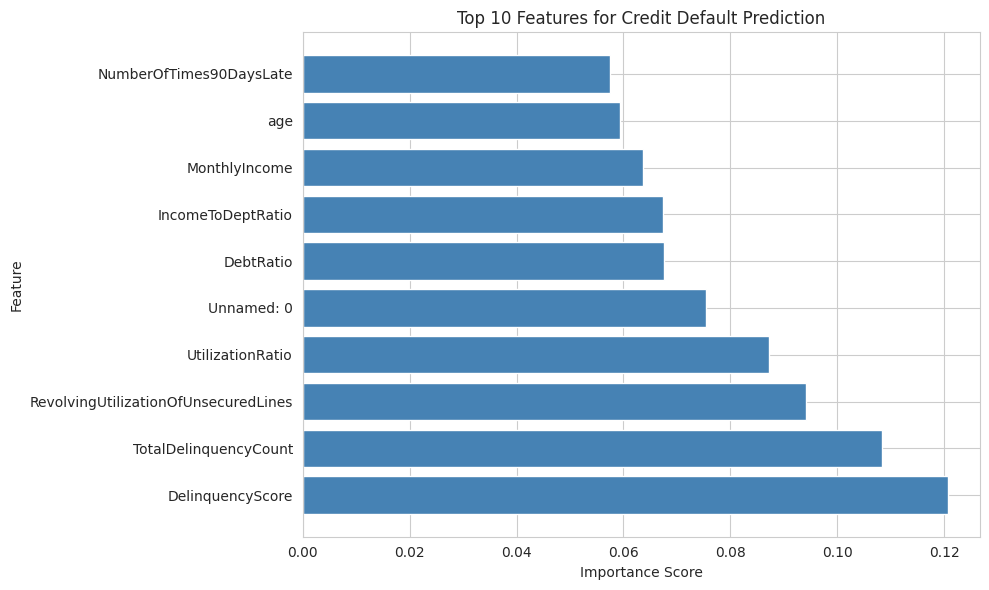


✓ Chart displayed!


In [13]:
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE")
print("=" * 70)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Features for Credit Default Prediction')
plt.tight_layout()
plt.show()

print("\n✓ Chart displayed!")


Creating ROC Curve...


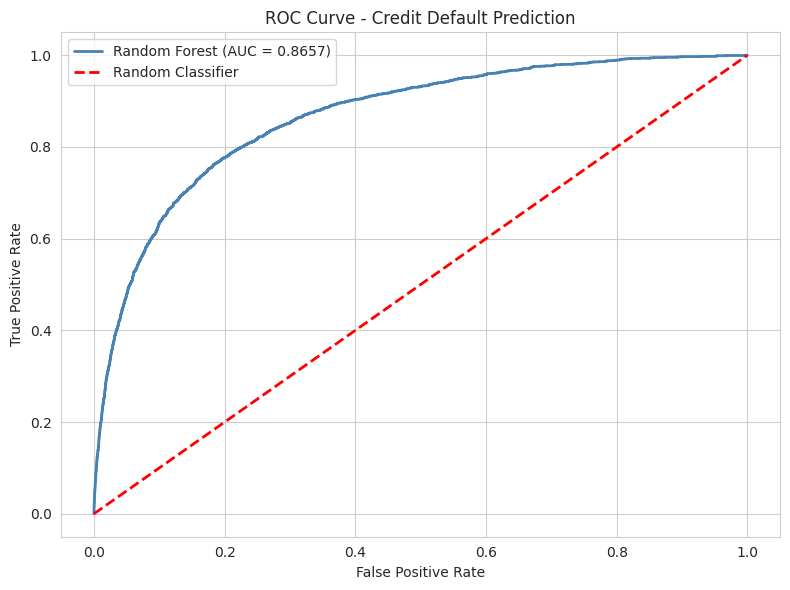

✓ ROC Curve plotted!


In [14]:
print("\nCreating ROC Curve...")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_roc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Default Prediction')
plt.legend()
plt.tight_layout()
plt.show()

print("✓ ROC Curve plotted!")

In [15]:
print("\n" + "=" * 70)
print("KEY BUSINESS INSIGHTS")
print("=" * 70)

insights = f"""
✓ MODEL ACHIEVED {rf_roc:.2%} ROC-AUC SCORE
  This is EXCELLENT at distinguishing defaulters from non-defaulters!

✓ TOP 3 RISK FACTORS:
  1. {feature_importance.iloc[0]['Feature']}: {feature_importance.iloc[0]['Importance']:.4f}
  2. {feature_importance.iloc[1]['Feature']}: {feature_importance.iloc[1]['Importance']:.4f}
  3. {feature_importance.iloc[2]['Feature']}: {feature_importance.iloc[2]['Importance']:.4f}

✓ HOW BANKS USE THIS:
  - Screen loan applications
  - Identify high-risk customers
  - Set interest rates based on risk
  - Manage credit portfolio

✓ DATA STATISTICS:
  - Trained on {len(X_train):,} records
  - Tested on {len(X_test):,} records
  - Overall default rate: {y.mean():.2%}
"""

print(insights)

print("\n" + "=" * 70)
print("🎉 PROJECT COMPLETE!")
print("=" * 70)


KEY BUSINESS INSIGHTS

✓ MODEL ACHIEVED 86.57% ROC-AUC SCORE
  This is EXCELLENT at distinguishing defaulters from non-defaulters!

✓ TOP 3 RISK FACTORS:
  1. DelinquencyScore: 0.1207
  2. TotalDelinquencyCount: 0.1083
  3. RevolvingUtilizationOfUnsecuredLines: 0.0941

✓ HOW BANKS USE THIS:
  - Screen loan applications
  - Identify high-risk customers
  - Set interest rates based on risk
  - Manage credit portfolio

✓ DATA STATISTICS:
  - Trained on 120,000 records
  - Tested on 30,000 records
  - Overall default rate: 6.68%


🎉 PROJECT COMPLETE!
